# **CPD Project 1**

**Group:** g16
- Miguel Neri, *up202006475*
- Filipe Camacho, *up202208040*
- 

## **Part 1, Item 1** — Basic matrix multiplication (`OnMult`) in C++ and Java

This section analyses the results collected for **Part 1 — Item 1** of the project statement.

The goal of this experiment is to compare the **basic matrix multiplication algorithm** between:
- **C++** (compiled with `-O2`)
- **Java**

for square matrices from **1024×1024** to **3072×3072**, with increments of **512**.

### 1. Experiment description

In this first experiment, both languages implement the same baseline algorithm, which multiplies one row of the first matrix by one column of the second matrix.

For each matrix size, the benchmark was repeated 5 times and the raw measurements were stored in a CSV file.  
The analysis below aggregates those repeated executions and visualises:

- **Execution time**
- **Performance in GFlop/s**
- **Selected hardware-counter trends collected with `perf`**
- **Derived cache miss rates**


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ModuleNotFoundError: No module named 'pandas'

### 2. Load the benchmark data


In [ ]:
possible_paths = [
    Path.cwd() / "results" / "part1_onmult_raw.csv",
    Path.cwd() / "doc" / "results" / "part1_onmult_raw.csv",
    Path.cwd() / "part1_onmult_raw.csv",
    Path("/mnt/data/part1_onmult_raw.csv"),  # fallback for the generated artifact
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find part1_onmult_raw.csv")

raw = pd.read_csv(csv_path)
raw.head()

,timestamp,part,experiment,variant,language,size,threads,block_size,run,time_seconds,gflops,speedup,efficiency,task_clock,instructions,cycles,cache_references,cache_misses,L1_dcache_loads,L1_dcache_load_misses,LLC_loads,LLC_load_misses,mem_load_retired_l1_miss,mem_load_retired_l2_miss
0,2026-03-19T14:57:04,1,onmult,base,C++,1024,1,NaN,1,2.7579,0.7787,NaN,NaN,2725467874,7577584012,13457495594,1848114864,1194898,2162700288,1053892507,1039849450,117028,981859432,969891626
1,2026-03-19T14:57:09,1,onmult,base,C++,1024,1,NaN,2,2.8078,0.7648,NaN,NaN,2757921409,7596139382,13478987495,1813451847,1936951,2165915260,1054366033,1042949302,473812,984293714,973200112
2,2026-03-19T14:57:15,1,onmult,base,C++,1024,1,NaN,3,2.7795,0.7726,NaN,NaN,2724854491,7588521694,13490623528,1862073597,1364101,2164773186,1054371882,1045865714,178527,981225038,978224414
3,2026-03-19T14:57:20,1,onmult,base,C++,1024,1,NaN,4,2.7780,0.7730,NaN,NaN,2739510846,7598494735,13539304581,1830759092,1785231,2167561846,1055410006,1046474839,279944,981377291,974922475
4,2026-03-19T14:57:26,1,onmult,base,C++,1024,1,NaN,5,2.7749,0.7739,NaN,NaN,2744241808,7578490255,13522046536,1816998162,1763125,2165263516,1054670429,1045518648,406727,984969996,975745927


### 3. Prepare the dataset

Since each configuration was executed multiple times, the notebook computes:
- the **mean**
- the **standard deviation**
- the **minimum and maximum**

for the most relevant metrics.


In [ ]:
df = raw.copy()

df = df[
    (df["part"] == 1) &
    (df["experiment"] == "onmult") &
    (df["variant"] == "base")
].copy()

numeric_cols = [
    "size", "threads", "run", "time_seconds", "gflops",
    "task_clock", "instructions", "cycles",
    "cache_references", "cache_misses",
    "L1_dcache_loads", "L1_dcache_load_misses",
    "LLC_loads", "LLC_load_misses",
    "mem_load_retired_l1_miss", "mem_load_retired_l2_miss"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["L1_miss_rate_pct"] = 100 * df["L1_dcache_load_misses"] / df["L1_dcache_loads"]
df["LLC_miss_rate_pct"] = 100 * df["LLC_load_misses"] / df["LLC_loads"]
df["IPC"] = df["instructions"] / df["cycles"]

summary = (
    df.groupby(["language", "size"], as_index=False)
      .agg(
          runs=("run", "count"),
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          time_min=("time_seconds", "min"),
          time_max=("time_seconds", "max"),
          gflops_mean=("gflops", "mean"),
          gflops_std=("gflops", "std"),
          L1_miss_rate_mean=("L1_miss_rate_pct", "mean"),
          LLC_miss_rate_mean=("LLC_miss_rate_pct", "mean"),
          IPC_mean=("IPC", "mean"),
      )
      .sort_values(["language", "size"])
)

summary

NameError: name 'raw' is not defined

### 4. Execution time by matrix size

This plot compares the average execution time for the basic algorithm in C++ and Java.  
Error bars represent one standard deviation across repeated runs.


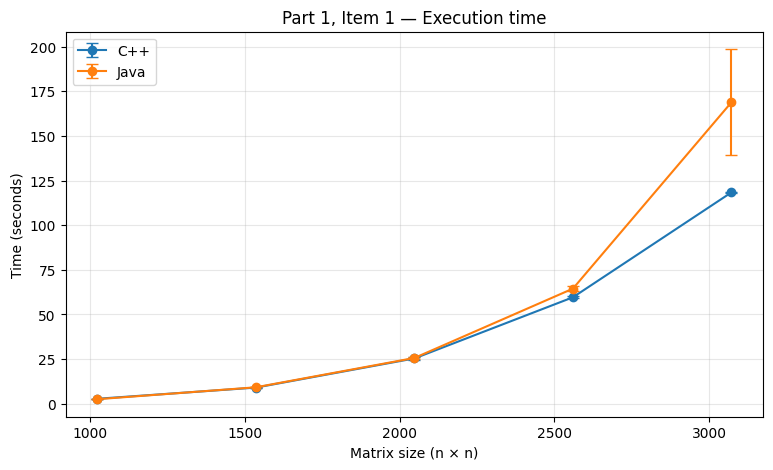

In [ ]:
fig, ax = plt.subplots()

for lang in sorted(summary["language"].unique()):
    s = summary[summary["language"] == lang].sort_values("size")
    ax.errorbar(
        s["size"], s["time_mean"], yerr=s["time_std"],
        marker="o", capsize=4, label=lang
    )

ax.set_title("Part 1, Item 1 — Execution time")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.show()

### 5. Performance in GFlop/s


$\mathrm{GFlop/s} = \frac{2n^3}{\text{Execution Time} \times 10^9}$

The next plot compares the average performance obtained for both languages.


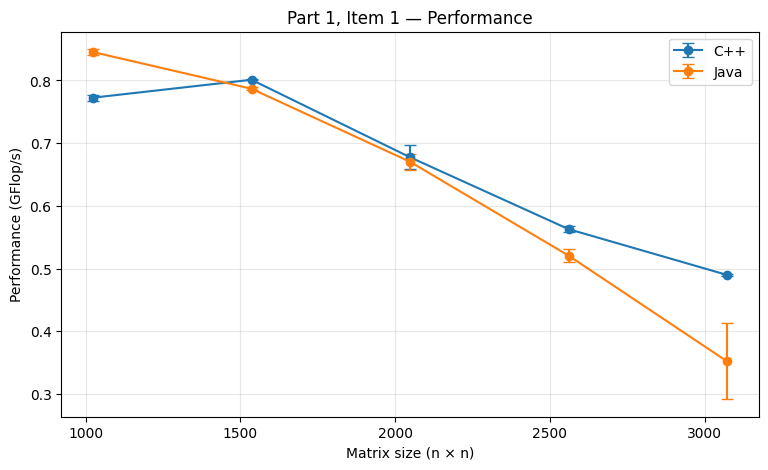

In [ ]:
fig, ax = plt.subplots()

for lang in sorted(summary["language"].unique()):
    s = summary[summary["language"] == lang].sort_values("size")
    ax.errorbar(
        s["size"], s["gflops_mean"], yerr=s["gflops_std"],
        marker="o", capsize=4, label=lang
    )

ax.set_title("Part 1, Item 1 — Performance")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Performance (GFlop/s)")
ax.legend()
plt.show()

### 6. Raw repetition spread

To complement the averaged curves, the following scatter plot shows every individual run.  
This helps visualise the variability of the benchmark across repetitions.

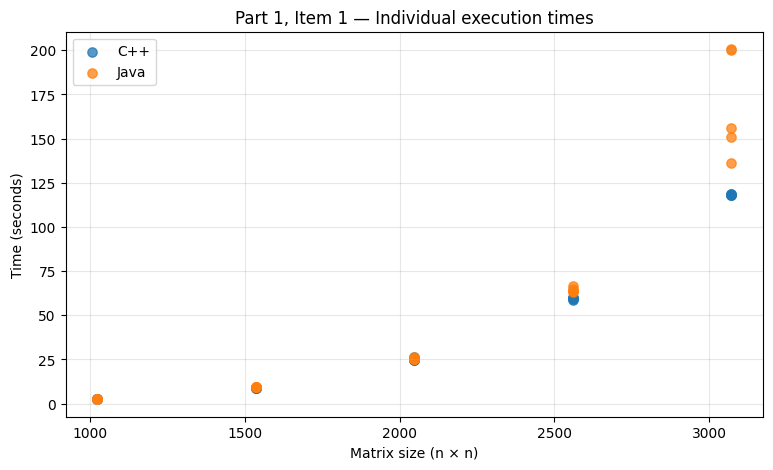

In [ ]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = df[df["language"] == lang].sort_values(["size", "run"])
    ax.scatter(d["size"], d["time_seconds"], s=45, alpha=0.75, label=lang)

ax.set_title("Part 1, Item 1 — Individual execution times")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.show()

### 7. Cache-related counters

Besides time and GFlop/s, the benchmark also collected hardware counters with `perf`.  
The next plots focus on two derived indicators:

- **L1 data-cache miss rate**
- **Last-level cache (LLC) miss rate**

These rates are computed from the collected load and miss counters.

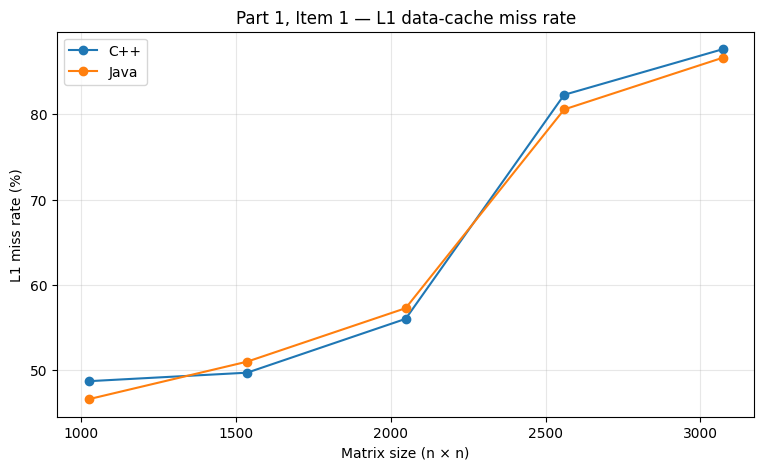

In [ ]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["L1_miss_rate_pct"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["L1_miss_rate_pct"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — L1 data-cache miss rate")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("L1 miss rate (%)")
ax.legend()
plt.show()

In [7]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["LLC_miss_rate_pct"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["LLC_miss_rate_pct"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — LLC miss rate")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("LLC miss rate (%)")
ax.legend()
plt.show()

NameError: name 'plt' is not defined

### 8. Additional processor metrics

The final plots in this section show:
- **instructions per cycle (IPC)**
- **task clock**

These metrics help characterise the execution beyond raw runtime alone.

In [6]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["IPC"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["IPC"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — Instructions per cycle (IPC)")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("IPC")
ax.legend()
plt.show()

NameError: name 'plt' is not defined

In [5]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["task_clock"]
        .mean()
        .sort_values("size")
    )
    d["task_clock_seconds"] = d["task_clock"] / 1e9
    ax.plot(d["size"], d["task_clock_seconds"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — Task clock")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Task clock (seconds)")
ax.legend()
plt.show()

NameError: name 'plt' is not defined

---

## **Part 1, Item 2** — Matrix multiplication with linear access (`OnMultLine`)

This section analyses the results collected for **Part 1 — Item 2**.

The `OnMultLine` implementation changes the inner loops to multiply an element from the first matrix by the corresponding line of the second matrix. This significantly alters the sequence in which memory is accessed. As explained in Ulrich Drepper's paper *What Every Programmer Should Know About Memory*, sequentially traversing memory leverages spatial locality. It drastically reduces RAM access latencies by capitalising on cache line bursts, minimizing RAS (Row Address Selection) to CAS (Column Address Selection) bottlenecks and letting hardware prefetchers work efficiently.

We compare the processing time and performance for:
- **C++** and **Java** (1024×1024 to 3072×3072, intervals of 512)
- **C++ extended** (4096×4096 to 10240×10240, intervals of 2048)

### 1. Load the benchmark data (OnMultLine)

In [ ]:
possible_paths_2 = [
    Path.cwd() / "results" / "part1_onmultline_raw.csv",
    Path.cwd() / "doc" / "results" / "part1_onmultline_raw.csv",
    Path.cwd() / "part1_onmultline_raw.csv",
]

csv_path_2 = next((p for p in possible_paths_2 if p.exists()), None)
if csv_path_2 is None:
    raise FileNotFoundError("Could not find part1_onmultline_raw.csv")

raw2 = pd.read_csv(csv_path_2)
raw2.head()

### 2. Prepare the dataset

Similarly to the first item, we calculate standard variables (mean, std) and cache miss rates.

In [ ]:
df2 = raw2.copy()

df2 = df2[
    (df2["part"] == 1) &
    (df2["experiment"] == "onmultline") &
    (df2["variant"] == "base")
].copy()

for col in numeric_cols:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors="coerce")

df2["L1_miss_rate_pct"] = 100 * df2["L1_dcache_load_misses"] / df2["L1_dcache_loads"]
df2["LLC_miss_rate_pct"] = 100 * df2["LLC_load_misses"] / df2["LLC_loads"]
df2["IPC"] = df2["instructions"] / df2["cycles"]

summary2 = (
    df2.groupby(["language", "size"], as_index=False)
      .agg(
          runs=("run", "count"),
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          time_min=("time_seconds", "min"),
          time_max=("time_seconds", "max"),
          gflops_mean=("gflops", "mean"),
          gflops_std=("gflops", "std"),
          L1_miss_rate_mean=("L1_miss_rate_pct", "mean"),
          LLC_miss_rate_mean=("LLC_miss_rate_pct", "mean"),
          IPC_mean=("IPC", "mean"),
      )
      .sort_values(["language", "size"])
)

summary2

### 3. Execution time and Performance by matrix size

The next plots compare the execution time and average performance obtained for the C++ and Java implementations of `OnMultLine`. 
Notice the impact of the spatial locality on execution speeds when compared to `OnMult`. C++ results are tracked up to 10240x10240, while Java stops at 3072x3072.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for lang in sorted(summary2["language"].unique()):
    s = summary2[summary2["language"] == lang].sort_values("size")
    ax1.errorbar(
        s["size"], s["time_mean"], yerr=s["time_std"],
        marker="o", capsize=4, label=lang
    )
    ax2.errorbar(
        s["size"], s["gflops_mean"], yerr=s["gflops_std"],
        marker="o", capsize=4, label=lang
    )

ax1.set_title("Part 1, Item 2 — Execution time")
ax1.set_xlabel("Matrix size (n × n)")
ax1.set_ylabel("Time (seconds)")
ax1.legend()

ax2.set_title("Part 1, Item 2 — Performance")
ax2.set_xlabel("Matrix size (n × n)")
ax2.set_ylabel("Performance (GFlop/s)")
ax2.legend()

plt.show()

### 4. Cache-related counters (OnMultLine)

The memory access pattern sequentially walking across the dataset allows us to capitalise on hardware cache-line fills efficiently, largely lowering the **L1 data-cache miss rate** when compared to the `OnMult` item previously analysed.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for lang in sorted(df2["language"].unique()):
    d = (
        df2[df2["language"] == lang]
        .groupby("size", as_index=False)[["L1_miss_rate_pct", "LLC_miss_rate_pct"]]
        .mean()
        .sort_values("size")
    )
    ax1.plot(d["size"], d["L1_miss_rate_pct"], marker="o", label=lang)
    ax2.plot(d["size"], d["LLC_miss_rate_pct"], marker="o", label=lang)

ax1.set_title("Part 1, Item 2 — L1 data-cache miss rate")
ax1.set_xlabel("Matrix size (n × n)")
ax1.set_ylabel("L1 miss rate (%)")
ax1.legend()

ax2.set_title("Part 1, Item 2 — LLC miss rate")
ax2.set_xlabel("Matrix size (n × n)")
ax2.set_ylabel("LLC miss rate (%)")
ax2.legend()

plt.show()

---
## **Part 1, Item 3** — Block-oriented matrix multiplication (`OnMultBlock`)

This item focuses on another strategy: breaking the matrix down into sub-blocks smaller than the cache tier capacities (sizes 128, 256, 512) reducing capacity cache misses heavily for massive matrices.
We evaluate its properties using the C++ language configuration.

In [ ]:
possible_paths_3 = [
    Path.cwd() / "results" / "part1_onmultblock_raw.csv",
    Path.cwd() / "doc" / "results" / "part1_onmultblock_raw.csv",
    Path.cwd() / "part1_onmultblock_raw.csv",
]

csv_path_3 = next((p for p in possible_paths_3 if p.exists()), None)
if csv_path_3 is None:
    raise FileNotFoundError("Could not find part1_onmultblock_raw.csv")

df3 = pd.read_csv(csv_path_3)

for col in numeric_cols:
    if col in df3.columns:
        df3[col] = pd.to_numeric(df3[col], errors="coerce")

df3["L1_miss_rate_pct"] = 100 * df3["L1_dcache_load_misses"] / df3["L1_dcache_loads"]

summary3 = (
    df3.groupby(["size", "block_size"], as_index=False)
      .agg(
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          gflops_mean=("gflops", "mean"),
          gflops_std=("gflops", "std"),
          L1_miss_rate_mean=("L1_miss_rate_pct", "mean")
      )
      .sort_values(["size", "block_size"])
)
summary3.head()

### Execution time and GFlop/s depending on block dimensions

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for block_val in sorted(df3["block_size"].dropna().unique()):
    s = summary3[summary3["block_size"] == block_val].sort_values("size")
    ax1.errorbar(
        s["size"], s["time_mean"], yerr=s["time_std"],
        marker="o", capsize=4, label=f"Block {int(block_val)}"
    )
    ax2.errorbar(
        s["size"], s["gflops_mean"], yerr=s["gflops_std"],
        marker="o", capsize=4, label=f"Block {int(block_val)}"
    )

ax1.set_title("Part 1, Item 3 — Execution time (OnMultBlock)")
ax1.set_xlabel("Matrix size (n × n)")
ax1.set_ylabel("Time (seconds)")
ax1.legend()

ax2.set_title("Part 1, Item 3 — Performance (OnMultBlock)")
ax2.set_xlabel("Matrix size (n × n)")
ax2.set_ylabel("Performance (GFlop/s)")
ax2.legend()

plt.show()

---
## **Part 2, Item 1** — Multi-core implementation mapping (4 threads)

In this session, we investigate multithreading through **OpenMP** applied to both `OnMult` and `OnMultLine` constructs utilizing **4 CPU threads**.  
We focus heavily on finding the derived **speedup**, **efficiency**, and absolute **GFlop/s** to pinpoint execution ceilings due to parallel core allocations.

In [ ]:
possible_paths_p2_1 = [
    Path.cwd() / "results" / "part2_1_raw.csv",
    Path.cwd() / "doc" / "results" / "part2_1_raw.csv",
    Path.cwd() / "part2_1_raw.csv",
]

csv_path_p2_1 = next((p for p in possible_paths_p2_1 if p.exists()), None)
if csv_path_p2_1 is None:
    raise FileNotFoundError("Could not find part2_1_raw.csv")

df_p2_1 = pd.read_csv(csv_path_p2_1)

for col in numeric_cols:
    if col in df_p2_1.columns:
        df_p2_1[col] = pd.to_numeric(df_p2_1[col], errors="coerce")
        
summary_p2_1 = (
    df_p2_1.groupby(["variant", "size"], as_index=False)
      .agg(
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          gflops_mean=("gflops", "mean"),
          speedup_mean=("speedup", "mean"),
          speedup_std=("speedup", "std"),
          efficiency_mean=("efficiency", "mean"),
          efficiency_std=("efficiency", "std"),
      )
      .sort_values(["variant", "size"])
)
summary_p2_1.head()

### 1. Execution Speedup & Efficiency using 4 Threads

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for var in sorted(summary_p2_1["variant"].unique()):
    s = summary_p2_1[summary_p2_1["variant"] == var].sort_values("size")
    ax1.errorbar(
        s["size"], s["speedup_mean"], yerr=s["speedup_std"],
        marker="o", capsize=4, label=var
    )
    ax2.errorbar(
        s["size"], s["efficiency_mean"], yerr=s["efficiency_std"],
        marker="o", capsize=4, label=var
    )

ax1.set_title("Part 2, Item 1 — Speedup (4 Threads)")
ax1.set_xlabel("Matrix size (n × n)")
ax1.set_ylabel("Speedup")
ax1.legend()

ax2.set_title("Part 2, Item 1 — Efficiency (4 Threads)")
ax2.set_xlabel("Matrix size (n × n)")
ax2.set_ylabel("Efficiency = (Speedup / 4)")
ax2.legend()

plt.show()

---
## **Part 2, Item 2** — Scaling and Advanced OpenMP Pragmas

We transition to exclusively analyzing **Version 2 (`OnMultLine`)** pegged to a large fixed matrix of **8192×8192**.  
The target is monitoring throughput whilst toggling **threads spanning configurations ranging from 4 up to 24**.

We benchmark simple parallel-for setups against advanced compiler directives like `#pragma omp for simd` (requesting hardware instruction-level vectorization) and `#pragma omp parallel for collapse(2)` (increasing depth-of-threading tasks by compressing two bounds into a single scope).

In [ ]:
possible_paths_p2_2 = [
    Path.cwd() / "results" / "part2_2_raw.csv",
    Path.cwd() / "doc" / "results" / "part2_2_raw.csv",
    Path.cwd() / "part2_2_raw.csv",
]

csv_path_p2_2 = next((p for p in possible_paths_p2_2 if p.exists()), None)
if csv_path_p2_2 is None:
    raise FileNotFoundError("Could not find part2_2_raw.csv")

df_p2_2 = pd.read_csv(csv_path_p2_2)

for col in numeric_cols:
    if col in df_p2_2.columns:
        df_p2_2[col] = pd.to_numeric(df_p2_2[col], errors="coerce")

summary_p2_2 = (
    df_p2_2.groupby(["variant", "threads"], as_index=False)
      .agg(
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          gflops_mean=("gflops", "mean"),
          gflops_std=("gflops", "std"),
          speedup_mean=("speedup", "mean"),
          speedup_std=("speedup", "std")
      )
      .sort_values(["variant", "threads"])
)
summary_p2_2.head()

### Performance vs Hardware Limits

Observing these graphs indicates where multi-threading plateaus or accelerates due to memory bottlenecks (bus constraints to the Northbridge or limits within local unified cache coherency protocols).

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for var in sorted(summary_p2_2["variant"].unique()):
    s = summary_p2_2[summary_p2_2["variant"] == var].sort_values("threads")
    # Speedup
    ax1.errorbar(
        s["threads"], s["speedup_mean"], yerr=s["speedup_std"],
        marker="o", capsize=4, label=var
    )
    # GFlop/s
    ax2.errorbar(
        s["threads"], s["gflops_mean"], yerr=s["gflops_std"],
        marker="o", capsize=4, label=var
    )

ax1.set_title("Part 2, Item 2 — Speedup Scalability")
ax1.set_xlabel("Number of threads")
ax1.set_ylabel("Speedup")
ax1.set_xticks([4, 8, 12, 16, 20, 24])
ax1.legend()

ax2.set_title("Part 2, Item 2 — Performance (GFlop/s)")
ax2.set_xlabel("Number of threads")
ax2.set_ylabel("Performance (GFlop/s)")
ax2.set_xticks([4, 8, 12, 16, 20, 24])
ax2.legend()

plt.show()

---
## **Conclusions**

By mapping our benchmark data to the fundamental architectural traits of system memory and cache behavior, we observe the following:

### 1. Algorithm Access Patterns (Single Core CPU Caches)
As explored in Ulrich Drepper's *What Every Programmer Should Know About Memory*, modern CPU speeds drastically outpace the capabilities of the Front Side Bus connecting to the DRAM memory. Therefore, how data is formatted and accessed plays an immense role mathematically.
- **OnMult (Basic)**: Calculates column by column over the second matrix. This disjoint jumping violates the principles of spatial locality. It forces costly repeated RAS (Row Address Selection) commands logic before column latency logic (CAS), constantly generating L1 data-cache misses because pre-fetched hardware cache lines are continuously evicted down before being comprehensively used.
- **OnMultLine**: Traverses the second matrix across lines. This aligns natively with how DRAM memory vectors are pushed to L1 caches in single block transfers ("cache-line fills" / bursts). Successive data is sitting exactly in adjacency to previously fetched operations causing high "hit" rates. The massive reduction in L1 data-cache miss rates effectively slashes elapsed computation times.
- **OnMultBlock**: Further sub-divides large monolithic datasets into small "tiles". This technique strictly exploits temporal locality, maintaining a functional "working set" that fits precisely within the tight capacity levels of fast L1/L2 memory, preventing the cache thrashing traditionally generated by traversing elements too massive to fit into LLC boundaries simultaneously.

### 2. Parallelisation Hardware Limits (Multi-core)
- **Bottlenecking OpenMP**: Tossing parallel threads to offset slow execution only speeds tasks linearly up to the bandwidth cap. A badly-designed algorithm like `OnMult` merely accelerates the system bottleneck towards memory contention limits. CPUs begin constantly fighting over the shared memory channels (FSB) requesting conflicting disjoint segments to operate.
- **SIMD Pragmas**: `#pragma omp for simd` utilizes physical processor vectoring capability (e.g., AVX hardware registers), squeezing multiple computations parallelized within the exactly constrained clock cycles. 
- **Collapse Mapping**: `#pragma omp parallel for collapse(2)` expands the flat iteration pool given to the scheduler by grouping two loop depths into one linear sequence. This permits finer grain load-balancing arrays amongst threads which increases the aggregate GFlop/s thresholds observed in larger multithreaded bounds (16 to 24 Threads).